## 1. Setup & Paths

In [1]:
import numpy as np
import pandas as pd
import torch
import time
import json
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

## 2. Load Embeddings & Labels

In [2]:
EMB_PATH = Path("../data/processed/protein_esm2_embeddings_top10_per400.npy")
LAB_PATH = Path("../data/processed/protein_esm2_labels_top10_per400.npy")

X = np.load(EMB_PATH)
y = np.load(LAB_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("n_classes:", len(np.unique(y)))

X shape: (2293, 480)
y shape: (2293,)
n_classes: 10


## 3. Stratified Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1834, 480)
Test: (459, 480)


## 4. Compute Class Weights

In [4]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.8008733624454148), np.int64(1): np.float64(1.2226666666666666), np.int64(2): np.float64(1.1320987654320989), np.int64(3): np.float64(1.834), np.int64(4): np.float64(1.890721649484536), np.int64(5): np.float64(1.1832258064516128), np.int64(6): np.float64(0.655), np.int64(7): np.float64(0.7425101214574898), np.int64(8): np.float64(1.951063829787234), np.int64(9): np.float64(0.573125)}


## 5. Model Zoo

In [5]:
models = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs"
     ))
    ]),
    
    "linear_svm": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CalibratedClassifierCV(
    LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        dual=False
    ),
    method="sigmoid"
     ))
    ]),
    
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "xgboost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        objective="multi:softprob",
        eval_metric="mlogloss",
        num_class=len(classes),
        tree_method="hist",
        random_state=42
    )
}

## 6. Cross-Validation (Macro Metrics)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    print(f"\nCV Training: {name}")
    t0 = time.time()
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=-1
    )
    
    cv_results.append({
        "model": name,
        "accuracy_mean": np.mean(scores["test_accuracy"]),
        "f1_macro_mean": np.mean(scores["test_f1_macro"]),
        "f1_weighted_mean": np.mean(scores["test_f1_weighted"]),
        "seconds": time.time() - t0
    })

cv_df = pd.DataFrame(cv_results).sort_values("f1_macro_mean", ascending=False)
cv_df


CV Training: logreg

CV Training: linear_svm

CV Training: random_forest

CV Training: xgboost


,model,accuracy_mean,f1_macro_mean,f1_weighted_mean,seconds
1,linear_svm,0.987456,0.987187,0.987329,57.842901
0,logreg,0.986912,0.986039,0.986795,3.575056
3,xgboost,0.961286,0.956028,0.960589,55.567010
2,random_forest,0.957469,0.951480,0.955921,8.247736


## 7. Final Training + Test Evaluation

In [7]:
test_results = []

SAVE_DIR = Path("../models/protein/esm2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for name, model in models.items():
    print(f"\nTraining final model: {name}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    
    test_results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })
    
    joblib.dump(model, SAVE_DIR / f"{name}_esm2.pkl")

test_df = pd.DataFrame(test_results).sort_values("f1_macro", ascending=False)
test_df


Training final model: logreg

Training final model: linear_svm

Training final model: random_forest

Training final model: xgboost


,model,accuracy,f1_macro,f1_weighted
1,linear_svm,0.986928,0.989041,0.986928
0,logreg,0.984749,0.986173,0.984733
3,xgboost,0.971678,0.971009,0.971420
2,random_forest,0.967320,0.964180,0.966917


## 8. Confusion Matrix (Best Model)

In [8]:
import matplotlib.pyplot as plt
best_model_name = test_df.iloc[0]["model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

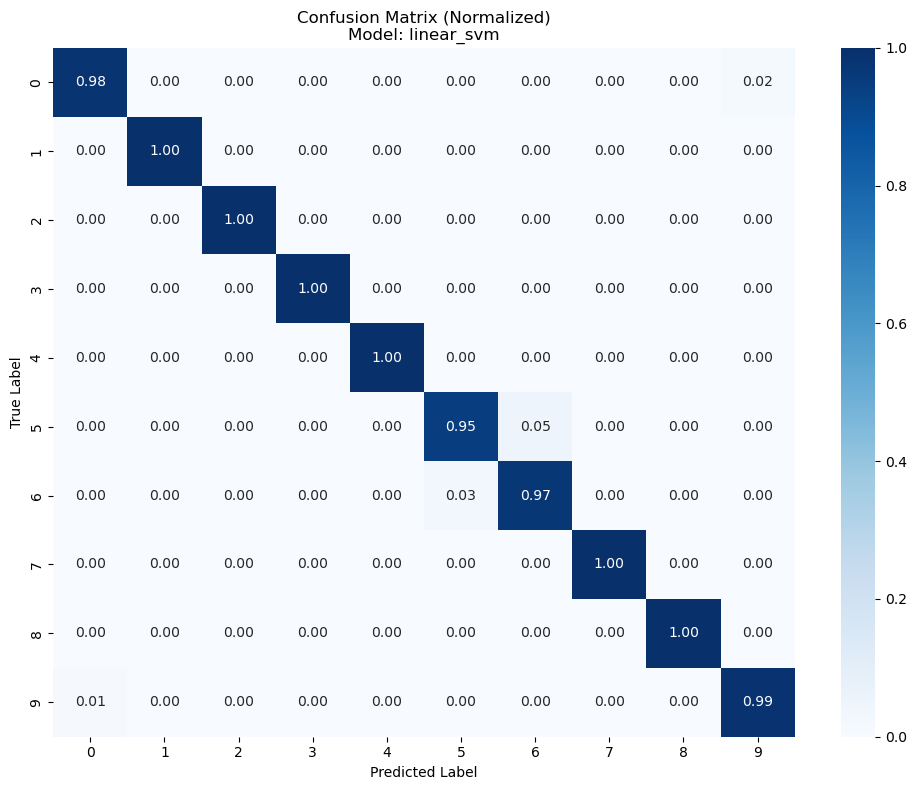

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize per true class (row-wise)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Normalized)\nModel: {best_model_name}")

plt.tight_layout()
plt.show()

## 9. Save Summary

In [10]:
summary = {
    "cv_results": cv_results,
    "test_results": test_results,
    "n_samples": int(len(y)),
    "embedding_dim": int(X.shape[1]),
    "n_classes": int(len(classes))
}

with open(SAVE_DIR / "esm2_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary.")

Saved summary.


In [12]:
import pandas as pd
import numpy as np

feat_path = "../data/processed/protein_features_baseline_top10_per400.csv"
df_feat = pd.read_csv(feat_path)

print("Shape:", df_feat.shape)
print("\nColumns:")
print(df_feat.columns[:10])
print("\nHead:")
print(df_feat.head())

Shape: (2293, 178)

Columns:
Index(['accession', 'family', 'seq_len', 'frac_A', 'frac_C', 'frac_D',
       'frac_E', 'frac_F', 'frac_G', 'frac_H'],
      dtype='str')

Head:
  accession   family  seq_len    frac_A    frac_C    frac_D    frac_E  \
0    Q96RD1  PF13853      312  0.044872  0.032051  0.028846  0.016026   
1    Q9H210  PF13853      308  0.068182  0.029221  0.022727  0.016234   
2    Q8NGZ3  PF13853      307  0.068404  0.029316  0.019544  0.029316   
3    O60412  PF13853      319  0.043887  0.034483  0.028213  0.021944   
4    Q8NGS0  PF13853      311  0.067524  0.045016  0.028939  0.022508   

     frac_F    frac_G    frac_H  ...  red7_di_FE  red7_di_FF  red7_di_FG  \
0  0.096154  0.025641  0.019231  ...    0.009646    0.003215         0.0   
1  0.058442  0.042208  0.022727  ...    0.006515    0.000000         0.0   
2  0.065147  0.035831  0.029316  ...    0.009804    0.000000         0.0   
3  0.075235  0.062696  0.021944  ...    0.006289    0.003145         0.0   
4  0.07